# Describing a DM halo

This is an example using the `DMHalo` class to configuring and create a DM halo, including the subestructure.

To create a DM halo we need to specify the scale density $\rho_s$, the scale radius $r_s$, and $R_{200}$.

You also need to give a name to the halo and provide the coordinates and redshift. Other factors are needed to compute 
all the relevant quantities and properties related to the halo as the fraction of the total mass given in the form of 
subhalos, the minimum and maximum masses of subhalos, the concentration relation for the main halo and the subhalos.

Then, the class compute the luminosity distance to the cluster and provides the cartesian coordinates in a flat 
$\Lambda$CDM cosmology with reduced Hubble constant $h$ (also provided at the moment of initialization, 
the default is 0.71). This is useful for the calculation of meshgrids used to define source distributions 
for the `CRpropa` plugin. The class also computes the total mass of the cluster $M_{200}$ (enclosed up to $R_{200}$). 
Other quantities and parameters computed are:

1. Saturation Density $\rho_\text{sat}$
2. Saturation Radius $r_\text{sat}$
3. (Spherical) Astrophysical J factor (DM annihilation)
4. (Spherical) Astrophysical D factor (DM decay)
5. Global normalization of the subhalo Probability Density Function
6. Concentration parameter of the host halo
7. Total number of subhalos in the range $[m_\text{min},m_\text{max}]$

A function for the Probability Density Function (PDF) for subhalos is also provided 
after proper calculation of normalization factors.

More details about all the related calculations can be found in the dedicated Github project.

Here, we use some toy parameters to describe a DM halo associated to a galaxy cluster. The name of 
the cluster is Abell and it is assumed to be located at a redshift $z$ of 0.0308. The concentration 
of the subhalos is computed using the relationship from [Moliné +, 2017] that include tidal effects.

We provide a convenient `info` method to print the information of your DM halo toy.

Please note that for the astrophysical factors we added the term spherical. This is because 
we are interested in the astrophysical factor without considering the projection along the 
line of sight of an observer.

As for now, the only density profile available is the Navarro-Frenk-White (NFW), but for future 
analysis we plan to introduce other density profiles.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from elfdannagalac.dmsrc import DMHalo

from elfdannagalac.substructure import (
    p_nsub_v,
    p_nsub_v_int,
    p_nsub_c,
    p_nsub_c_int
)

from elfdannagalac.tools import convert_mass,convert_density
from elfdannagalac.dmsrc.dmsource import get_rhosat

In [2]:
rs   = 0.3*u.Mpc
rhos = 7.01e5*u.M_sun/u.kpc**3
r200 = 3*u.Mpc
rhosat = get_rhosat(100*u.GeV,3.6e-24*u.cm**3/u.s)

print(convert_mass(0.1*u.TeV,new_unit=u.GeV))
print(rhosat)
print(convert_density(rhosat,new_unit=u.Msun/rs.unit**3))


100.0 GeV
8333333333333333.0 solMass / kpc3
8.333333333333334e+24 solMass / Mpc3


In [3]:

abel_cluster = DMHalo(
    "Abel",
    12*u.deg,
    27*u.deg,
    0.0308,
    rs,
    rhos,
    r200,
    dmsigmav=3.6e-24*u.cm**3/u.s,
    msub_min=3.5410271e9*u.Msun,
    msub_max=3.54e12*u.Msun,
    fsub=0.11,
    mpoints=5
)

/data/disk01/home/skerzot/anaconda3/envs/edmcanna/lib/python3.10/site-packages/elfdannagalac/astrofactors/jfactor.py:83: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  jfactor_02 = quad(


In [4]:
abel_cluster.info

2026-02-02 01:18:02.778 | INFO     | elfdannagalac.dmsrc.halo:info:250 - 
Abel cluster configured with: 
	- Redshift: 0.031
	- D_lum: 129.474 Mpc
	- Coord: (12.000 deg,27.000 deg) [ICRS]
	- X: 112.841 Mpc
	- Y: 23.985 Mpc
	- Z: 58.780 Mpc
	- Scale radius: 0.300 Mpc
	- Scale density: 7.010e+14 solMass / Mpc3
	- Saturation Radius: 2.524e-11 Mpc
	- Saturation Density: 8.333e+24 solMass / Mpc3
	- Cluster Radius [R200]: 3.000 Mpc
	- Total Mass [M200]: 3.541e+14 solMass
	- Number of subhalos: 1225  (from [3.541e+09 solMass,3.540e+12 solMass])
	- Total mass in form of subhalos: 3.893e+13 solMass (11.0% of the cluster mass)
	- (Spherical) Anna J factor [No sub]: 2.202e+40 solMass2 / Mpc5 (9.795e+31 GeV2 / cm5)
	- (Spherical) Decay D factor [No sub]: 6.130e+16 solMass / Mpc2 (7.181e+24 GeV / cm2)



In [5]:
abel_cluster.rhos.to(u.GeV/u.cm**3,equivalencies=u.mass_energy())

<Quantity 0.02661358 GeV / cm3>

In [6]:
abel_cluster.c_subhalo(1e10*u.M_sun,0.1*u.Mpc)

23.922012298433312

In [7]:
abel_cluster.c200

16.331302392387176

In [8]:
masses = np.logspace(-5,15,100)
csubs  = abel_cluster.c_subhalo(masses*u.M_sun,0.3*u.Mpc)

Text(0, 0.5, '$c_{200}$')

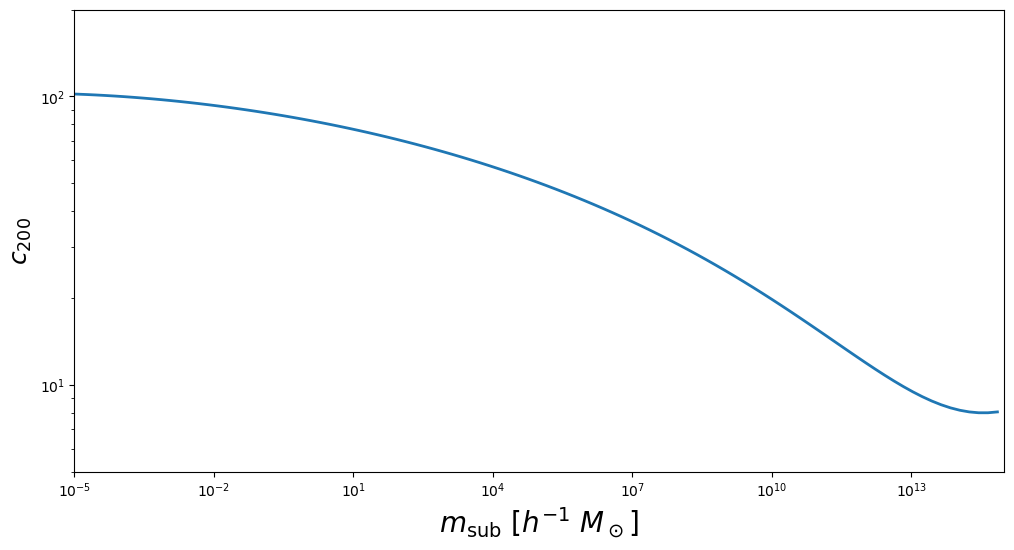

In [9]:
_,ax = plt.subplots(figsize=(12,6))

ax.plot(masses*0.71,csubs,lw=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-5,1e15)
ax.set_ylim(5,200)
ax.set_xlabel(r"$m_\text{sub}$ [$h^{-1}~M_\odot$]",fontsize=20)
ax.set_ylabel(r"$c_{200}$",fontsize=18)

In [10]:
p = p_nsub_v(
        1.5*u.Mpc,abel_cluster.rs,
        abel_cluster.rhos,
        abel_cluster.r_sat,
        abel_cluster.rho_sat,
        abel_cluster.m200)
print(f"{p:0.3e}")

1.100e-02 1 / Mpc3


In [11]:
rs   = np.logspace(np.log10(0.01*abel_cluster.rs.value),np.log10(abel_cluster.r200.value))
dndv = np.zeros_like(rs)/abel_cluster.r200.unit**3

for i,r in enumerate(rs):
    dndv[i] = p_nsub_v(
        r*u.Mpc,
        abel_cluster.rs,
        abel_cluster.rhos,
        abel_cluster.r_sat,
        abel_cluster.rho_sat,
        abel_cluster.m200
    )


(0.003, 3.0)

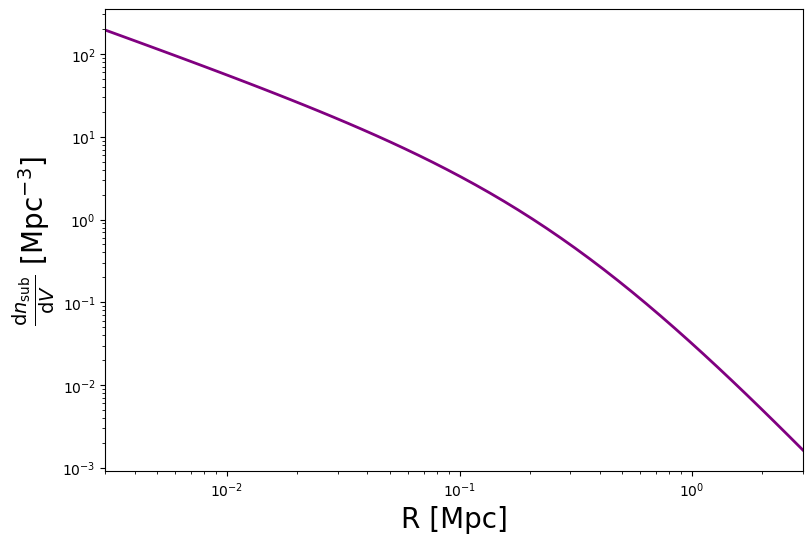

In [12]:
_,ax = plt.subplots(figsize=(9,6))

ax.plot(rs,dndv,lw=2,color="purple")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"R [Mpc]",fontsize=20)
ax.set_ylabel(r"$\frac{\text{d}n_\text{sub}}{\text{d}V}$ [Mpc$^{-3}$]",fontsize=20)
ax.set_xlim(0.01*abel_cluster.rs.value,abel_cluster.r200.value)
# ax.set_ylim(1e-3,1e2)

In [13]:
p = p_nsub_v_int(
        1e-5*u.Mpc,
        abel_cluster.rs,
        abel_cluster.rhos,
        abel_cluster.r_sat,
        abel_cluster.rho_sat,
        abel_cluster.m200,
    )

print(f"dnsub_dV test: {p:0.3e}")

dnsub_dV test: 3.731e-10


In [14]:
mass   = 1.3e8*u.M_sun
rtest  = 0.25*u.Mpc
cvals  = np.linspace(1,300)
prob_c = p_nsub_c(cvals,0.13,mass,rtest,abel_cluster.r200,0.71,clabel="moline2017")

Text(0, 0.5, 'Prob')

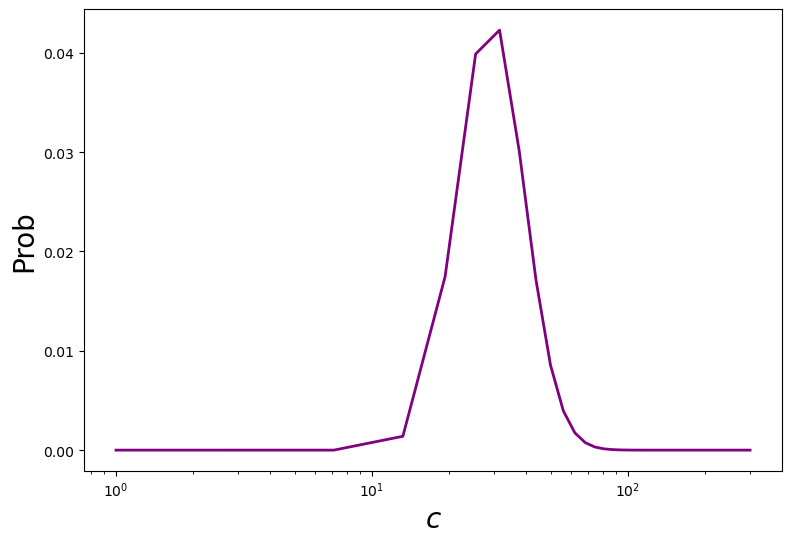

In [15]:
_,ax = plt.subplots(figsize=(9,6))

ax.plot(cvals,prob_c,lw=2,color="purple")

ax.set_xscale("log")
ax.set_xlabel(r"$c$",fontsize=20)
ax.set_ylabel("Prob",fontsize=20)



In [16]:
p_nsub_c_int(1,300,0.2,mass,rtest,abel_cluster.r200,0.71,clabel="moline2017")

0.9999994683934607

In [17]:
print(abel_cluster.nsubs)

1225


In [18]:
print(abel_cluster.msubs)

38930302455221.1 solMass


In [19]:
rvals = np.logspace(
    np.log10(0.01*abel_cluster.rs.value),
    np.log10(abel_cluster.r200.value),
    100
)

dndr = np.zeros_like(rvals)/u.Mpc**3

for i,r in enumerate(rvals):

    dndr[i] = abel_cluster.dnsubdr(r*u.Mpc)

(0.003, 3.0)

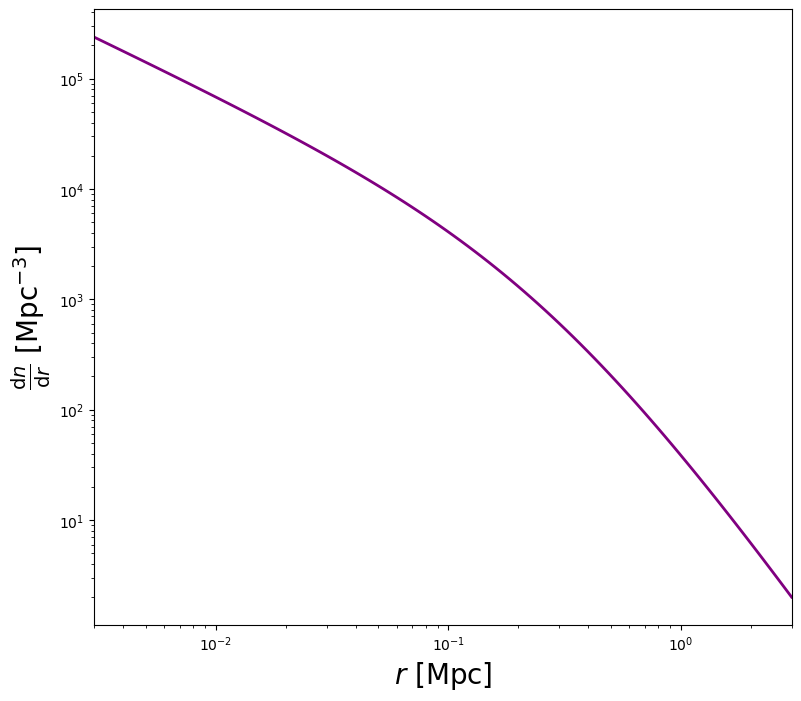

In [20]:
_,ax = plt.subplots(figsize=(9,8))

ax.plot(rvals,dndr,lw=2,color="purple")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$r$ [Mpc]",fontsize=20)
ax.set_ylabel(r"$\frac{{\rm d}n}{{\rm d}r}$ [Mpc$^{-3}$]",fontsize=20)
ax.set_xlim(0.01*abel_cluster.rs.value,abel_cluster.r200.value)